# scarico dati

In [3]:
import os
import sys
import urllib.request
from io import BytesIO

from astroML.datasets import fetch_dr7_quasar
import astroML.datasets.dr7_quasar as dr7
from astroML.datasets.tools.download import bytes_to_string

# Patch AstroML download to handle servers that omit Content-Length header.
# This prevents KeyError during download.

def _download_with_progress_bar_fixed(data_url, return_buffer=False):
    num_units = 40
    fhandle = urllib.request.urlopen(data_url)

    info = dict(fhandle.info())
    content_length = info.get('Content-Length')
    if content_length is not None:
        content_length = int(content_length.strip())
        chunk_size = max(1, content_length // num_units)
    else:
        # fallback to a sensible chunk size when total size is unknown
        chunk_size = 1024 * 1024
        content_length = None

    print("Downloading %s" % data_url)
    nchunks = 0
    buf = BytesIO()

    while True:
        next_chunk = fhandle.read(chunk_size)
        nchunks += 1
        if next_chunk:
            buf.write(next_chunk)
            if content_length is not None:
                s = ('[' + nchunks * '='
                     + (num_units - 1 - nchunks) * ' '
                     + ']  {} / {}   \r'.format(bytes_to_string(buf.tell()),
                                                bytes_to_string(content_length)))
                sys.stdout.write(s)
                sys.stdout.flush()
        else:
            if content_length is not None:
                sys.stdout.write('\n')
            break

    buf.seek(0)
    if return_buffer:
        return buf
    else:
        return buf.getvalue()

# Apply the patch to the module that fetch_dr7_quasar uses.
dr7.download_with_progress_bar = _download_with_progress_bar_fixed

# Remove any partially downloaded file so fetch_dr7_quasar will re-download.
# The cache directory is typically '~/astroML_data'.
if os.path.exists(os.path.expanduser('~/astroML_data/dr7qso.npy')):
    os.remove(os.path.expanduser('~/astroML_data/dr7qso.npy'))



# import

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats

goals:
- Upsample this distribution in hopefully two ways (but at least one of them), using both rejection sampling and inverse transform.
- Check, at least visually, that the two cloned distribitions are indeed similar to the observed one (for a quantitative check, come back to this point in a few lectures)
- Think about the cosmology of quasars. How do you think they are distributed? Overplot the theorethical distribution to the measured SDSS data. Does that agree with your expectation? 

(Hint: It shouldn't. But why?) 

# Code

In [ ]:
import os
import sys
import urllib.request
from io import BytesIO

from astroML.datasets import fetch_dr7_quasar
data = fetch_dr7_quasar()

# select the first 10000 points
data = data[:]

z = data['redshift']

(array([2.100e+01, 8.500e+01, 1.670e+02, 3.460e+02, 5.550e+02, 6.120e+02,
        7.690e+02, 1.069e+03, 1.159e+03, 1.170e+03, 1.258e+03, 1.158e+03,
        1.221e+03, 1.344e+03, 1.318e+03, 1.379e+03, 1.310e+03, 1.284e+03,
        1.383e+03, 1.344e+03, 1.424e+03, 1.402e+03, 1.493e+03, 1.358e+03,
        1.484e+03, 1.499e+03, 1.715e+03, 1.723e+03, 1.847e+03, 1.694e+03,
        1.719e+03, 2.006e+03, 2.005e+03, 1.735e+03, 1.923e+03, 1.953e+03,
        1.796e+03, 1.798e+03, 1.907e+03, 2.018e+03, 2.183e+03, 2.338e+03,
        2.093e+03, 2.058e+03, 2.157e+03, 1.860e+03, 2.317e+03, 2.238e+03,
        1.895e+03, 2.114e+03, 1.885e+03, 1.772e+03, 1.753e+03, 1.399e+03,
        1.334e+03, 1.415e+03, 1.308e+03, 1.109e+03, 1.177e+03, 9.270e+02,
        8.570e+02, 7.940e+02, 6.580e+02, 5.580e+02, 5.710e+02, 5.500e+02,
        4.830e+02, 4.680e+02, 3.890e+02, 3.650e+02, 2.740e+02, 3.000e+02,
        2.850e+02, 2.350e+02, 2.680e+02, 2.190e+02, 2.260e+02, 2.650e+02,
        3.090e+02, 3.520e+02, 3.970e+0

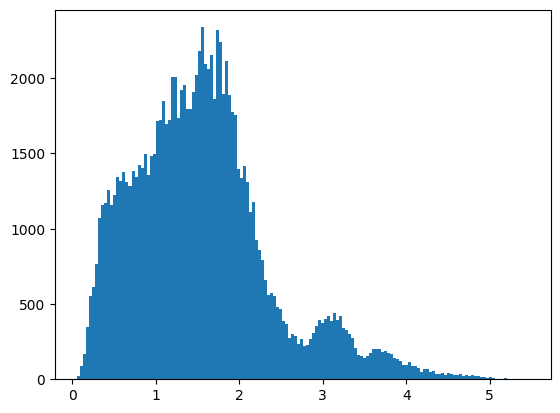

In [4]:
plt.hist (z, bins = 150)


## rejection sampling

In [5]:
bin, edges = np.histogram(z, bins = 200)


def rs(bin, edges, npoints):
    #calcolo il punto medio dei bins
    #normalizzo l'integrale
    x_mean = np.zeros(len(bin))
    area = 0
    for i in range (len(bin)):
        x_mean[i] = (edges[i + 1] - edges[i])
        area += x_mean[i] * bin[i]
        x_mean[i] = x_mean[i] / 2
    # print(x_mean.shape)
    x = []
    max_index = len(bin) 
    max_height = np.max(bin) / area
    while (len (x) < npoints):
        x_candidate = np.random.uniform(edges[0], edges[-1])
        y_candidate = np.random.uniform(0, max_height)
        for j in range (len (bin)):
            if (x_candidate >= edges[j] and x_candidate < edges[j + 1]):
                if (y_candidate < ( bin[j] / area)):
                    #accept the result
                    x.append( x_candidate )
    return x

(array([2.200e+01, 6.900e+01, 1.670e+02, 3.250e+02, 4.950e+02, 5.990e+02,
        7.610e+02, 9.720e+02, 1.111e+03, 1.142e+03, 1.150e+03, 1.060e+03,
        1.170e+03, 1.240e+03, 1.230e+03, 1.221e+03, 1.248e+03, 1.213e+03,
        1.250e+03, 1.267e+03, 1.331e+03, 1.392e+03, 1.369e+03, 1.303e+03,
        1.367e+03, 1.502e+03, 1.567e+03, 1.720e+03, 1.767e+03, 1.645e+03,
        1.643e+03, 1.856e+03, 1.885e+03, 1.797e+03, 1.709e+03, 1.832e+03,
        1.746e+03, 1.696e+03, 1.773e+03, 1.999e+03, 2.033e+03, 2.185e+03,
        1.948e+03, 1.946e+03, 2.035e+03, 1.695e+03, 2.067e+03, 2.238e+03,
        1.869e+03, 1.916e+03, 1.788e+03, 1.669e+03, 1.625e+03, 1.332e+03,
        1.315e+03, 1.289e+03, 1.257e+03, 1.096e+03, 1.067e+03, 8.590e+02,
        7.920e+02, 7.490e+02, 7.080e+02, 5.390e+02, 5.420e+02, 4.850e+02,
        4.690e+02, 4.250e+02, 3.440e+02, 3.290e+02, 2.730e+02, 2.740e+02,
        2.520e+02, 2.390e+02, 2.830e+02, 2.170e+02, 2.440e+02, 2.380e+02,
        2.790e+02, 3.200e+02, 3.740e+0

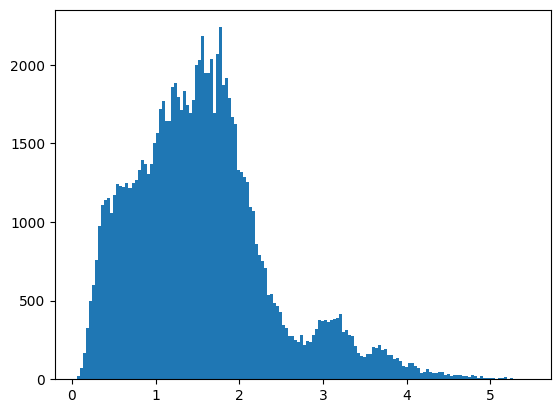

In [6]:
values = 100000
x = rs(bin, edges, values)
plt.hist(x, bins = 150)

## Inverse transform

In [7]:
def it(bin, edges, npoints):
    cdf = np.cumsum(bin) / np.sum(bin)  #summing (discrete integration) all the values to that point over normalization
    x_mean = np.zeros(len(bin))
    for i in range(len(bin)-1): 
        x_mean[i] =( edges[i + 1] + edges[i]) / 2
    unif_dist = np.random.uniform(0, 1, npoints)
    # print(unif_dist.shape, cdf.shape, x_mean.shape)
    new_x = np.interp(unif_dist, cdf, x_mean)
    return new_x


(array([4.500e+01, 7.300e+01, 1.300e+02, 2.640e+02, 3.090e+02, 4.260e+02,
        4.450e+02, 4.880e+02, 6.860e+02, 8.020e+02, 8.600e+02, 8.690e+02,
        8.390e+02, 8.670e+02, 8.390e+02, 8.450e+02, 8.700e+02, 9.120e+02,
        9.840e+02, 9.660e+02, 9.580e+02, 9.110e+02, 9.000e+02, 9.290e+02,
        9.460e+02, 9.360e+02, 1.021e+03, 9.680e+02, 1.041e+03, 1.011e+03,
        1.006e+03, 9.820e+02, 1.125e+03, 1.080e+03, 1.100e+03, 1.233e+03,
        1.244e+03, 1.281e+03, 1.198e+03, 1.182e+03, 1.248e+03, 1.404e+03,
        1.413e+03, 1.235e+03, 1.281e+03, 1.246e+03, 1.262e+03, 1.329e+03,
        1.306e+03, 1.265e+03, 1.273e+03, 1.382e+03, 1.417e+03, 1.506e+03,
        1.599e+03, 1.559e+03, 1.424e+03, 1.437e+03, 1.530e+03, 1.389e+03,
        1.334e+03, 1.539e+03, 1.609e+03, 1.511e+03, 1.374e+03, 1.517e+03,
        1.417e+03, 1.301e+03, 1.190e+03, 1.239e+03, 1.104e+03, 9.740e+02,
        9.570e+02, 9.610e+02, 9.870e+02, 9.040e+02, 8.820e+02, 8.150e+02,
        7.820e+02, 6.180e+02, 6.090e+0

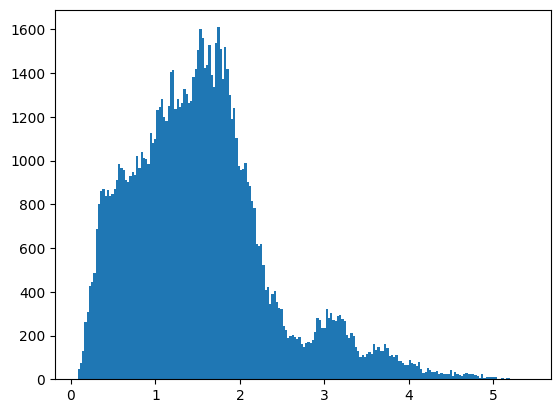

In [8]:
x1 = it(bin, edges, values)
plt.hist(x1, bins = 200)

## hist

In [ ]:
def luminosity_function_evolution(z):
    """
    ϕ(z) = ϕ_0 * (1+z)^α at z < z_peak
    ϕ(z) = ϕ_0 * (1+z_peak)^α * exp(-β*(z-z_peak)) at z > z_peak
    """
    z_peak = 2.3
    alpha = 2.8  # growth rate
    beta = 0.35  # decay rate
    phi_0 = 100  # normalization
    
    result = np.zeros_like(z)
    low_z = z <= z_peak
    high_z = z > z_peak
    
    result[low_z] = phi_0 * (1 + z[low_z])**alpha
    result[high_z] = phi_0 * (1 + z_peak)**alpha * np.exp(-beta * (z[high_z] - z_peak))
    
    return result


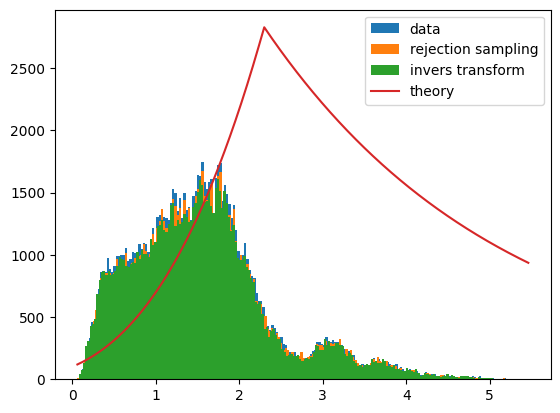

In [17]:
plt.hist(z, bins = 200, label = 'data')
plt.hist(x, bins = 200, label = 'rejection sampling')
plt.hist(x1, bins = 200, label = 'invers transform')
plt.plot(np.linspace(np.min(z), np.max(z), 1000), luminosity_function_evolution(np.linspace(np.min(z), np.max(z), 1000)), label = 'theory')
plt.legend()